In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from dmba import adjusted_r2_score
import math

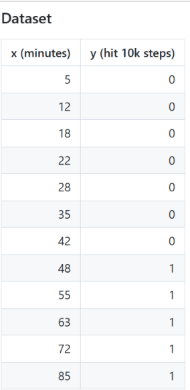

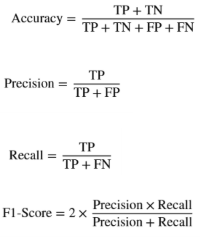

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, classification_report

x = np.array([5, 12, 18, 22, 28, 35, 42, 48, 55, 63, 72, 85]).reshape(-1, 1)
y = np.array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

# solver
model = LogisticRegression(solver='liblinear')

# fit 
model.fit(x, y)

# print b0, b1
b0 = model.intercept_[0] 
b1 = model.coef_[0][0]
print(f'b0 = {b0} | b1 = {b1}\n')

# find the x for 50%, 70% use the function below:
def x_for_probability(p, b0, b1):
    """The x at which the model predicts probability p."""
    return (np.log(p / (1 - p)) - b0) / b1
print(f'x 50% = {x_for_probability(0.5, b0, b1):.4f}')    
print(f'x 70% = {x_for_probability(0.7, b0, b1):.4f}\n')    

# print the confusion matrix
pred = model.predict(x)
print(f'confusion matrix = {confusion_matrix(y, pred)}\n')

# calc the acuuracy according to the confusion matrix, precision, recall, f1-score (1 is best, 0 is worst)
cm = confusion_matrix(y, pred)
TN, FP, FN, TP = cm.ravel()
print(f'TN = {TN} | FP = {FP} | FN = {FN} | TP = {TP}')
acuuracy = (TP + TN) / (TN + FP + FN + TP)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1_score = 2 * ((precision * recall) / (precision + recall))
print(f'acuuracy = {acuuracy}')
print(f'precision = {precision}')
print(f'recall = {recall}')
print(f'f1-score = {f1_score}\n')

print('accuracy:', accuracy_score(y, pred))
print(classification_report(y, pred, digits=3))

b0 = -1.4779204122407046 | b1 = 0.04192002010626461

x 50% = 35.2557
x 70% = 55.4680

confusion matrix = [[6 1]
 [0 5]]

TN = 6 | FP = 1 | FN = 0 | TP = 5
acuuracy = 0.9166666666666666
precision = 0.8333333333333334
recall = 1.0
f1-score = 0.9090909090909091

accuracy: 0.9166666666666666
              precision    recall  f1-score   support

           0      1.000     0.857     0.923         7
           1      0.833     1.000     0.909         5

    accuracy                          0.917        12
   macro avg      0.917     0.929     0.916        12
weighted avg      0.931     0.917     0.917        12

